In [105]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim.lr_scheduler as lr_scheduler
from torch import from_numpy as tnsr
from scipy.stats import bernoulli
import torch.nn as nn
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

# 3 hypothesis for sleep:
1. capacity improvement
2. homeostasis (balancing firing)
3. performance improvement
4. conversion to semantic memory in cortex

## Experiment 1:
### Observation: During sleep connections in Hippocampus weaken and connections in the cortical region strengthen.
### Hypothesis: Distributing learning to Neo-cortex gives Hippocampus more capacity.
 - During wake, train a hippocampus RNN (with lower hidden size) on the data, freeze the cortical RNN.
 - During sleep generate sequence from the trained RNN.
 - Now train both hippocampus + cortical RNN on the generated data.
 - After the sleep period in the second wake period, train only the hippocampus RNN, freezing the cortical RNN.

### Expectation: The hippocampus RNN now has better capacity.



## Proposed Model
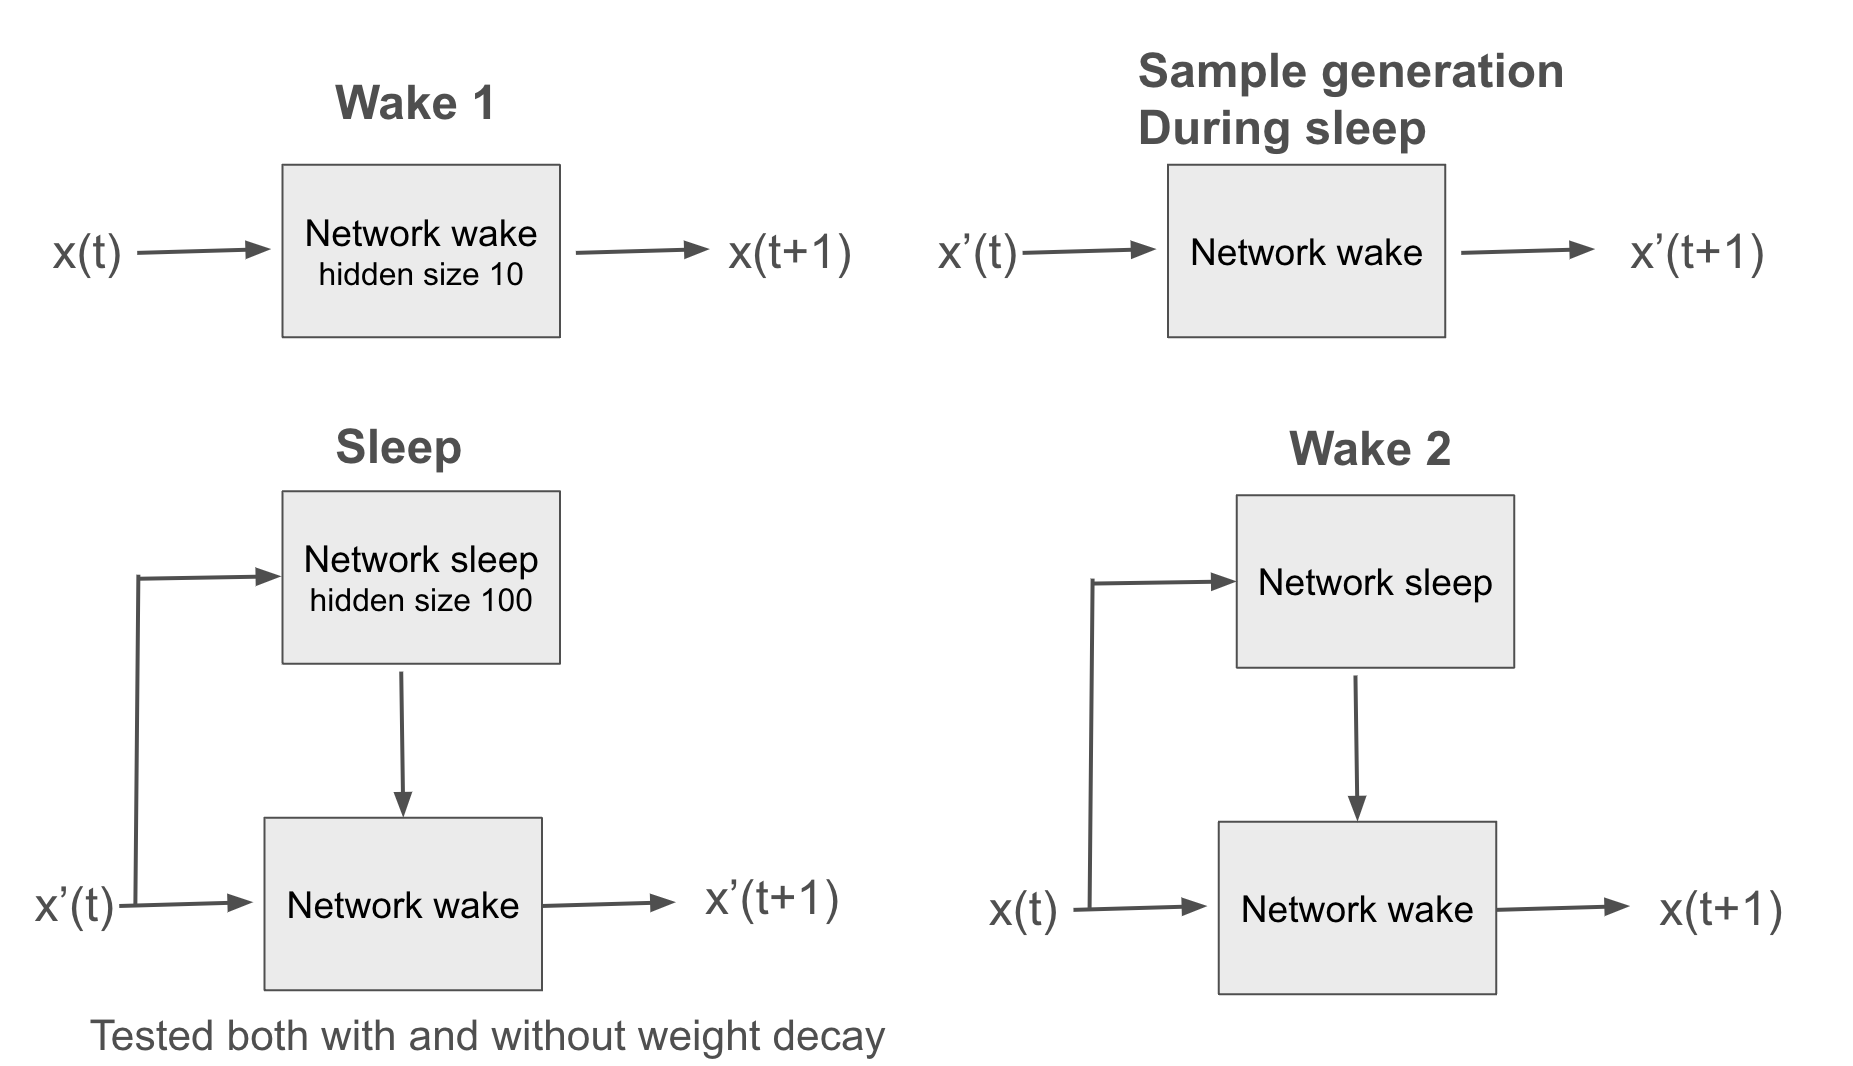

In [163]:
def _get_member(community, n_members, clockwise=True):
    seq = chr(community*n_members + ord('A'))
    
    if clockwise:
        next_token = chr(community*n_members + ord('A') + 1)
    else:
        next_token = chr(community*n_members + ord('A') + n_members-1)

    for _ in range(n_members-1):
        seq += next_token

        if clockwise:
            next_token = chr(ord(next_token) + 1)
        else:
            next_token = chr(ord(next_token) - 1)

    seq += seq[0]
    return seq 

def get_sequence(n_samples, n_community, n_members, random_state=0):
    
    """
    Generate data sequence divided into communities.

    Parameters
    ----------
    n_samples : int
        Total number of tokens to sample.
    n_community : int
        Total number of community.
    n_members : int
        Total number of members in each community.
    random_state : int, RandomState instance, default=None
        Determines random number generation for dataset creation. Pass an int
        for reproducible output across multiple function calls.

    Returns
    -------
    out : array of shape [n_samples]
        The generated sequence of tokens.
    """

    if random_state != None:
        np.random.seed(random_state)

    visits = []
    direction = []
    total_community_visit = int(np.ceil(n_samples/n_members))
    
    for ii in range(total_community_visit):
        visits.append(
            np.random.choice(n_community)
        )

        if ii == 0 or ii == 1:
            direction.append(True)
        elif visits[-2] == visits[-1] and visits[-3] == visits[-1]:
            direction.append(False)
        elif visits[-2] != visits[-1] and visits[-3] == visits[-1]:
            direction.append(True)
        elif visits[-2] == visits[-1] and visits[-3] != visits[-1]:
            direction.append(True)
        else:
            direction.append(False)

    out = ''
    for ii, community in enumerate(visits):
        out += _get_member(community, n_members, clockwise=direction[ii]) + chr(ord('A')+n_community*n_members)

    return out[:n_samples]
        

In [164]:
n_community = 2
n_members = 3

tokens = []

for ii in range(n_community*n_members+1):
    tokens.append(
        chr(ord('A')+ii)
    )

In [224]:
class RNN(nn.Module):
    def __init__(self, input_size, hidden_size_hippocampus, hidden_size_cortex, num_layers_hippocampus=1, num_layers_cortex=1, memory_buffer=10):
        super(RNN, self).__init__()
        self.cortex_hidden = torch.zeros(1, 1, hidden_size_cortex)
        
        self.hidden_size_cortex = hidden_size_cortex
        self.hidden_size_hippocampus = hidden_size_hippocampus
        self.rnn_hippocampus = nn.RNN(input_size+hidden_size_cortex, hidden_size_hippocampus, num_layers_hippocampus, batch_first=True)
        self.rnn_cortex = nn.RNN(input_size, hidden_size_cortex, num_layers_cortex, batch_first=True)
        
        self.fc = nn.Linear(hidden_size_hippocampus, len(tokens))
        
    def forward(self, x, h0=None, hc=None, sleep=False):
        if sleep:
            if hc == None:
                cortex_out, hc = self.rnn_cortex(x)
            else:
                cortex_out, hc = self.rnn_cortex(x, hc)
            
            x = torch.cat((x,cortex_out), dim=2)
                
            if h0 == None:
                out, h0 = self.rnn_hippocampus(x)
            else:   
                out, h0 = self.rnn_hippocampus(x, h0)
    
            out = self.fc(out)
        else:
            x = torch.cat((x,self.cortex_hidden), dim=2)
                
            if h0 == None:
                out, h0 = self.rnn_hippocampus(x)
            else:   
                out, h0 = self.rnn_hippocampus(x, h0)
    
            out = self.fc(out)
        
        
 
        # else:
        #     x = torch.cat((x,self.cortex_hidden), dim=2)
        #     if h0 == None:
        #         out, h0 = self.rnn_hippocampus(x)
        #     else:   
        #         out, h0 = self.rnn_hippocampus(x, h0)
            
        if sleep:
            return out[:,-1,:], h0, hc

        return out[:,-1,:], h0

In [225]:
class Dataset_converter(Dataset):
    def __init__(self, data, working_memory=1, short_term_memory=8):
        
        one_hot_encoded = np.zeros((len(data), len(tokens)), dtype=float)
        for ii, token in enumerate(data):
            one_hot_encoded[ii,ord(token)-65] = 1
        
        self.X = np.zeros((((len(data)-working_memory-short_term_memory)), short_term_memory, len(tokens)*working_memory))
        self.y = np.zeros((((len(data)-working_memory-short_term_memory)), len(tokens)))

        for ii in range(self.X.shape[0]):
            for jj in range(self.X.shape[1]):
                for kk in range(working_memory):
                    self.X[ii,jj,kk*len(tokens):(kk+1)*len(tokens)] = \
                    one_hot_encoded[ii+jj+kk,:]
                    
            self.y[ii] = \
                one_hot_encoded[ii+jj+kk+1,:]

        self.X = tnsr(self.X).float()
        self.y = tnsr(self.y).float()

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self):
        return self.X.shape[0]

In [229]:
def generate_sleep_samples(main_model, n_samples):
    seq = ''
    idx = torch.randint(0, len(tokens), (1,)) [0]
    X_hat = torch.zeros(len(tokens),dtype=torch.float32)
    X_hat[idx] = 1.0
    
    for ii in range(n_samples+50):
        if ii == 0:
            # seq += tokens[idx]        
            X_hat, mem = main_model(X_hat.reshape(1,1,-1))
        else:
            X_hat, mem = main_model(X_hat, mem)
    
        # mem = mem + 1e-1*torch.rand(mem.shape)
        # X_hat = torch.tensor(X_hat, requires_grad=False)
        X_hat = torch.nn.functional.softmax(X_hat, dim=1)
        dist_categ = torch.distributions.Categorical(probs=X_hat.reshape(-1))
        idx = dist_categ.sample()
    
        X_hat = torch.zeros(len(tokens),dtype=torch.float32)
        X_hat[idx] = 1.0
        X_hat = X_hat.reshape(1,1,-1)   
    
        if ii>50:
            seq += tokens[idx]

    return seq

In [234]:
### initial training ###
total_samples = 100000
initial_training_sample = 20000
sleep_samples = 20000
working_memory = 1
short_term_memory = 1
hidden_size_hippocampus = 10
hidden_size_cortex = 100
num_layers = 1
lr = 9e-4
reps = 5
test_acc = [[] for _ in range(reps)]

for rep in range(reps):
    print('Doing rep ', rep)
    
    data = get_sequence(total_samples, 2, 3, random_state=rep)
    # data = pd.read_csv("../Seq_500000.txt")['seq'][0]
    
    
    data_set = Dataset_converter(data[:initial_training_sample], working_memory, short_term_memory)
    
    main_model = RNN(len(tokens)*working_memory, hidden_size_hippocampus, hidden_size_cortex, num_layers)
    main_model.rnn_cortex.requires_grad = False
    
    train_loader = DataLoader(data_set, batch_size=1, shuffle=False) 
    
    optimizer = torch.optim.SGD(main_model.parameters(), lr=lr, momentum=0.95)
    criterion = torch.nn.CrossEntropyLoss()
    
    total = 0
    correct = np.zeros(1000,dtype=float)
    for X, y in train_loader:
        optimizer.zero_grad()
    
        if total == 0:
            predicted_y, hidden = main_model(X)
        else:
            predicted_y, hidden = main_model(X, mem)
            
        loss = criterion(predicted_y, y)
        loss.backward(retain_graph=True)
        optimizer.step()
    
        with torch.no_grad():
            mem = hidden.clone()
            
            true_y = y.argmax(axis=1)
            estimated_y = predicted_y.argmax(axis=1)
    
            total += 1
            if true_y == estimated_y:
                    correct[total%1000] = 1
            else:
                correct[total%1000] = 0
    
            test_acc[rep].append(
                np.sum(correct)/total if total<1000 else np.sum(correct)/1000
            )
            if total%1000 == 0:
                print(f'Iter : {total+1}, loss: {loss:.4f}, accuracy: {test_acc[rep][-1]:.4f}')


    print('Going to sleep ...')
    data_sleep = generate_sleep_samples(main_model, sleep_samples)
    main_model.rnn_cortex.requires_grad = True
    data_set = Dataset_converter(data_sleep, working_memory, short_term_memory)
    sleep_loader = DataLoader(data_set, batch_size=1, shuffle=False) 
    optimizer = torch.optim.Adam([
                                    {'params': main_model.rnn_hippocampus.parameters(), 'weight_decay': 1e-8},  # Apply weight decay to hippocampus
                                    {'params': main_model.rnn_cortex.parameters()},  # No weight decay for cortex
                                    {'params': main_model.fc.parameters()},
                                ], lr=lr)
    # optimizer = torch.optim.SGD(main_model.parameters(), lr=lr, momentum=0.95)
    
    criterion = torch.nn.CrossEntropyLoss()
    sleep_iter = 0
    
    for X, y in sleep_loader:
        optimizer.zero_grad()
    
        if sleep_iter == 0:
            predicted_y, hidden, hidden_sleep = main_model(X, sleep=True)
        else:
            predicted_y, hidden, hidden_sleep = main_model(X, mem, mem_, sleep=True)
            
        loss = criterion(predicted_y, y)
        loss.backward()
        optimizer.step()
    
        with torch.no_grad():
            mem = hidden.clone()
            mem_ = hidden_sleep.clone()
            
            true_y = y.argmax(axis=1)
            estimated_y = predicted_y.argmax(axis=1)
    
            sleep_iter += 1
            if true_y == estimated_y:
                    correct[sleep_iter%1000] = 1
            else:
                correct[sleep_iter%1000] = 0
    
            test_acc[rep].append(
                np.sum(correct)/total if total<1000 else np.sum(correct)/1000
            )
            if sleep_iter%1000 == 0:
                print(f'Iter : {sleep_iter+1}, loss: {loss:.4f}, accuracy: {test_acc[rep][-1]:.4f}')


    print('Going to awake phase ...')
    # data_sleep = generate_sleep_samples(main_model, sleep_samples)
    main_model.rnn_cortex.requires_grad = False
    data_set = Dataset_converter(data[initial_training_sample:], working_memory, short_term_memory)
    test_loader = DataLoader(data_set, batch_size=1, shuffle=False) 
    optimizer = torch.optim.SGD(main_model.parameters(), lr=lr, momentum=0.95)
    criterion = torch.nn.CrossEntropyLoss()
    sleep_iter = 0
    
    for X, y in test_loader:
        optimizer.zero_grad()
    
        if sleep_iter == 0:
            predicted_y, hidden, hidden_sleep = main_model(X, sleep=True)
        else:
            predicted_y, hidden, hidden_sleep = main_model(X, mem, mem_, sleep=True)
            
        loss = criterion(predicted_y, y)
        loss.backward()
        optimizer.step()
    
        with torch.no_grad():
            mem = hidden.clone()
            mem_ = hidden_sleep.clone()
            
            true_y = y.argmax(axis=1)
            estimated_y = predicted_y.argmax(axis=1)
    
            sleep_iter += 1
            if true_y == estimated_y:
                    correct[sleep_iter%1000] = 1
            else:
                correct[sleep_iter%1000] = 0
    
            test_acc[rep].append(
                np.sum(correct)/total if total<1000 else np.sum(correct)/1000
            )
            if sleep_iter%1000 == 0:
                print(f'Iter : {sleep_iter+1}, loss: {loss:.4f}, accuracy: {test_acc[rep][-1]:.4f}')


Doing rep  0
Iter : 1001, loss: 1.4302, accuracy: 0.4220
Iter : 2001, loss: 1.4374, accuracy: 0.7460
Iter : 3001, loss: 0.4471, accuracy: 0.7990
Iter : 4001, loss: 1.2191, accuracy: 0.7910
Iter : 5001, loss: 1.2163, accuracy: 0.8090
Iter : 6001, loss: 1.5038, accuracy: 0.7800
Iter : 7001, loss: 0.2930, accuracy: 0.7990
Iter : 8001, loss: 1.1635, accuracy: 0.8150
Iter : 9001, loss: 0.7529, accuracy: 0.8050
Iter : 10001, loss: 0.6550, accuracy: 0.8090
Iter : 11001, loss: 0.6776, accuracy: 0.7890
Iter : 12001, loss: 1.1501, accuracy: 0.8150
Iter : 13001, loss: 0.6433, accuracy: 0.8050
Iter : 14001, loss: 0.7847, accuracy: 0.7910
Iter : 15001, loss: 0.4223, accuracy: 0.7920
Iter : 16001, loss: 0.8452, accuracy: 0.8080
Iter : 17001, loss: 0.4479, accuracy: 0.8000
Iter : 18001, loss: 1.1774, accuracy: 0.7940
Iter : 19001, loss: 0.9015, accuracy: 0.7780
Going to sleep ...
Iter : 1001, loss: 0.0095, accuracy: 0.8010
Iter : 2001, loss: 0.7596, accuracy: 0.7940
Iter : 3001, loss: 0.0004, accurac

In [235]:
### initial training ###
reps = 5
test_acc_not_sparse = [[] for _ in range(reps)]

for rep in range(reps):
    print('Doing rep ', rep)
    
    data = get_sequence(total_samples, 2, 3, random_state=rep)
    # data = pd.read_csv("../Seq_500000.txt")['seq'][0]
    
    
    data_set = Dataset_converter(data[:initial_training_sample], working_memory, short_term_memory)
    
    main_model = RNN(len(tokens)*working_memory, hidden_size_hippocampus, hidden_size_cortex, num_layers)
    main_model.rnn_cortex.requires_grad = False
    
    train_loader = DataLoader(data_set, batch_size=1, shuffle=False) 
    
    optimizer = torch.optim.SGD(main_model.parameters(), lr=lr, momentum=0.95)
    criterion = torch.nn.CrossEntropyLoss()
    
    total = 0
    correct = np.zeros(1000,dtype=float)
    for X, y in train_loader:
        optimizer.zero_grad()
    
        if total == 0:
            predicted_y, hidden = main_model(X)
        else:
            predicted_y, hidden = main_model(X, mem)
            
        loss = criterion(predicted_y, y)
        loss.backward()
        optimizer.step()
    
        with torch.no_grad():
            mem = hidden.clone()
            true_y = y.argmax(axis=1)
            estimated_y = predicted_y.argmax(axis=1)
    
            total += 1
            if true_y == estimated_y:
                    correct[total%1000] = 1
            else:
                correct[total%1000] = 0
    
            test_acc_not_sparse[rep].append(
                np.sum(correct)/total if total<1000 else np.sum(correct)/1000
            )
            if total%1000 == 0:
                print(f'Iter : {total+1}, loss: {loss:.4f}, accuracy: {test_acc_not_sparse[rep][-1]:.4f}')


    print('Going to sleep ...')
    data_sleep = generate_sleep_samples(main_model, sleep_samples)
    main_model.rnn_cortex.requires_grad = True
    data_set = Dataset_converter(data_sleep, working_memory, short_term_memory)
    sleep_loader = DataLoader(data_set, batch_size=1, shuffle=False) 
    optimizer = torch.optim.SGD(main_model.parameters(), lr=lr, momentum=0.95)
    
    criterion = torch.nn.CrossEntropyLoss()
    sleep_iter = 0
    
    for X, y in sleep_loader:
        optimizer.zero_grad()
    
        if sleep_iter == 0:
            predicted_y, hidden, hidden_sleep = main_model(X, mem, sleep=True)
        else:
            predicted_y, hidden, hidden_sleep = main_model(X, mem, mem_, sleep=True)
            
        loss = criterion(predicted_y, y)
        loss.backward()
        optimizer.step()
    
        with torch.no_grad():
            mem = hidden.clone()
            mem_ = hidden_sleep.clone()
            
            true_y = y.argmax(axis=1)
            estimated_y = predicted_y.argmax(axis=1)
    
            sleep_iter += 1
            if true_y == estimated_y:
                    correct[sleep_iter%1000] = 1
            else:
                correct[sleep_iter%1000] = 0
    
            test_acc_not_sparse[rep].append(
                np.sum(correct)/total if total<1000 else np.sum(correct)/1000
            )
            if sleep_iter%1000 == 0:
                print(f'Iter : {sleep_iter+1}, loss: {loss:.4f}, accuracy: {test_acc_not_sparse[rep][-1]:.4f}')


    print('Going to awake phase ...')
    #data_sleep = generate_sleep_samples(main_model, sleep_samples)
    main_model.rnn_cortex.requires_grad = False
    data_set = Dataset_converter(data[initial_training_sample:], working_memory, short_term_memory)
    sleep_loader = DataLoader(data_set, batch_size=1, shuffle=False) 
    optimizer = torch.optim.SGD(main_model.parameters(), lr=lr, momentum=0.95)
    criterion = torch.nn.CrossEntropyLoss()
    sleep_iter = 0
    
    for X, y in sleep_loader:
        optimizer.zero_grad()
    
        if sleep_iter == 0:
            predicted_y, hidden, hidden_sleep = main_model(X, mem, sleep=True)
        else:
            predicted_y, hidden, hidden_sleep = main_model(X, mem, mem_, sleep=True)
            
        loss = criterion(predicted_y, y)
        loss.backward()
        optimizer.step()
    
        with torch.no_grad():
            mem = hidden.clone()
            mem_ = hidden_sleep.clone()
            
            true_y = y.argmax(axis=1)
            estimated_y = predicted_y.argmax(axis=1)
    
            sleep_iter += 1
            if true_y == estimated_y:
                    correct[sleep_iter%1000] = 1
            else:
                correct[sleep_iter%1000] = 0
    
            test_acc_not_sparse[rep].append(
                np.sum(correct)/total if total<1000 else np.sum(correct)/1000
            )
            if sleep_iter%1000 == 0:
                print(f'Iter : {sleep_iter+1}, loss: {loss:.4f}, accuracy: {test_acc_not_sparse[rep][-1]:.4f}')


Doing rep  0
Iter : 1001, loss: 1.3646, accuracy: 0.4530
Iter : 2001, loss: 1.1714, accuracy: 0.6760
Iter : 3001, loss: 0.4624, accuracy: 0.7760
Iter : 4001, loss: 1.0601, accuracy: 0.7880
Iter : 5001, loss: 1.2393, accuracy: 0.8150
Iter : 6001, loss: 1.1556, accuracy: 0.7740
Iter : 7001, loss: 0.4504, accuracy: 0.7970
Iter : 8001, loss: 1.1774, accuracy: 0.8180
Iter : 9001, loss: 0.8313, accuracy: 0.7900
Iter : 10001, loss: 0.7918, accuracy: 0.8030
Iter : 11001, loss: 0.7439, accuracy: 0.7970
Iter : 12001, loss: 0.9490, accuracy: 0.7990
Iter : 13001, loss: 0.5543, accuracy: 0.8000
Iter : 14001, loss: 0.7357, accuracy: 0.7920
Iter : 15001, loss: 0.4304, accuracy: 0.7850
Iter : 16001, loss: 0.8049, accuracy: 0.8060
Iter : 17001, loss: 0.5859, accuracy: 0.7900
Iter : 18001, loss: 1.0668, accuracy: 0.7880
Iter : 19001, loss: 0.7841, accuracy: 0.7720
Going to sleep ...
Iter : 1001, loss: 0.8058, accuracy: 0.8020
Iter : 2001, loss: 0.0080, accuracy: 0.7880
Iter : 3001, loss: 0.0133, accurac

In [236]:
### initial training ###
test_acc_control = [[] for _ in range(reps)]

for rep in range(reps):
    print('Doing rep ', rep)
    
    data = get_sequence(total_samples, 2, 3, random_state=rep)
    # data = pd.read_csv("../Seq_500000.txt")['seq'][0]
    
    
    data_set = Dataset_converter(data, working_memory, short_term_memory)
    
    main_model = RNN(len(tokens)*working_memory, hidden_size_hippocampus, hidden_size_cortex, num_layers)
    main_model.rnn_cortex.requires_grad = False
    
    train_loader = DataLoader(data_set, batch_size=1, shuffle=False) 
    
    optimizer = torch.optim.SGD(main_model.parameters(), lr=lr, momentum=0.95)
    criterion = torch.nn.CrossEntropyLoss()
    
    total = 0
    correct = np.zeros(1000,dtype=float)
    for X, y in train_loader:
        optimizer.zero_grad()
    
        if total == 0:
            predicted_y, hidden = main_model(X)
        else:
            predicted_y, hidden = main_model(X, mem)
            
        loss = criterion(predicted_y, y)
        loss.backward()
        optimizer.step()
    
        with torch.no_grad():
            mem = hidden.clone()
            true_y = y.argmax(axis=1)
            estimated_y = predicted_y.argmax(axis=1)
    
            total += 1
            if true_y == estimated_y:
                    correct[total%1000] = 1
            else:
                correct[total%1000] = 0
    
            test_acc_control[rep].append(
                np.sum(correct)/total if total<1000 else np.sum(correct)/1000
            )
            if total%1000 == 0:
                print(f'Iter : {total+1}, loss: {loss:.4f}, accuracy: {test_acc_control[rep][-1]:.4f}')



Doing rep  0
Iter : 1001, loss: 1.3717, accuracy: 0.4400
Iter : 2001, loss: 1.2972, accuracy: 0.7140
Iter : 3001, loss: 0.3723, accuracy: 0.8020
Iter : 4001, loss: 0.9449, accuracy: 0.8130
Iter : 5001, loss: 1.3089, accuracy: 0.8000
Iter : 6001, loss: 1.2677, accuracy: 0.7810
Iter : 7001, loss: 0.3809, accuracy: 0.7960
Iter : 8001, loss: 1.0752, accuracy: 0.8050
Iter : 9001, loss: 0.7235, accuracy: 0.7990
Iter : 10001, loss: 0.6273, accuracy: 0.8110
Iter : 11001, loss: 0.6506, accuracy: 0.7860
Iter : 12001, loss: 1.0570, accuracy: 0.8100
Iter : 13001, loss: 0.5732, accuracy: 0.8000
Iter : 14001, loss: 0.7780, accuracy: 0.7990
Iter : 15001, loss: 0.3633, accuracy: 0.7970
Iter : 16001, loss: 0.8785, accuracy: 0.8050
Iter : 17001, loss: 0.4129, accuracy: 0.8010
Iter : 18001, loss: 1.0727, accuracy: 0.7970
Iter : 19001, loss: 0.9600, accuracy: 0.7830
Iter : 20001, loss: 0.6365, accuracy: 0.8040
Iter : 21001, loss: 1.4943, accuracy: 0.7970
Iter : 22001, loss: 0.7893, accuracy: 0.8200
Iter :

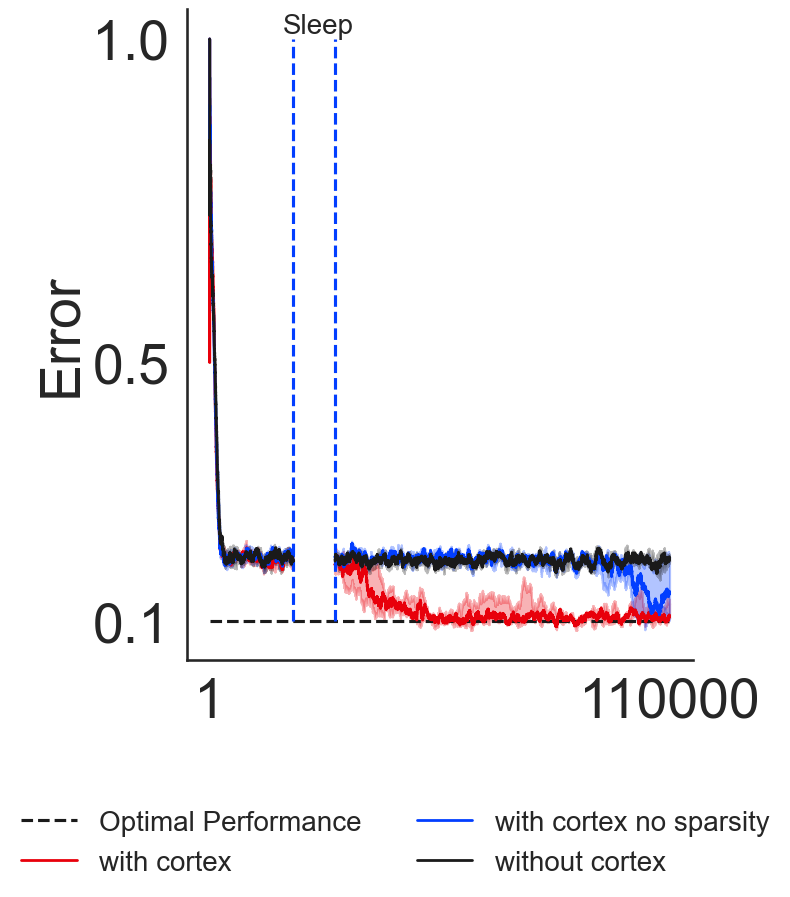

In [237]:
test_acc = np.array(test_acc)
test_acc_not_sparse = np.array(test_acc_not_sparse)
test_acc_control = np.array(test_acc_control)
sleep_break = 10000
sns.set(
        color_codes=True, palette="bright", style="white", context="talk", font_scale=1.5
    )
font = 40

fig, ax = plt.subplots(1, 1, figsize=(8,8), sharex=True, sharey=True)

ax.hlines(0.1, 0, total_samples+sleep_break, linestyles='dashed', label='Optimal Performance', color='k')

ax.plot(np.median(1-test_acc[:,:initial_training_sample],axis=0),linewidth=2, color='r', label='with cortex')
ax.fill_between(np.arange(1,initial_training_sample+1), np.quantile(1-test_acc[:,:initial_training_sample], 0.25, axis=0), np.quantile(1-test_acc[:,:initial_training_sample], 0.75, axis=0), color='r', alpha=.3)

ax.plot(np.arange(initial_training_sample+sleep_break,initial_training_sample+sleep_break+len(test_acc[0][initial_training_sample+sleep_samples:])), np.median(1-test_acc[:,initial_training_sample+sleep_samples:],axis=0),linewidth=2, color='r')
ax.fill_between(np.arange(initial_training_sample+sleep_break,initial_training_sample+sleep_break+len(test_acc[0][initial_training_sample+sleep_samples:])), np.quantile(1-test_acc[:,initial_training_sample+sleep_samples:], 0.25, axis=0), np.quantile(1-test_acc[:,initial_training_sample+sleep_samples:], 0.75, axis=0), color='r', alpha=.3)


ax.plot(np.median(1-test_acc_not_sparse[:,:initial_training_sample],axis=0),linewidth=2, color='b', label='with cortex no sparsity')
ax.fill_between(np.arange(1,initial_training_sample+1), np.quantile(1-test_acc_not_sparse[:,:initial_training_sample], 0.25, axis=0), np.quantile(1-test_acc_not_sparse[:,:initial_training_sample], 0.75, axis=0), color='b', alpha=.3)

ax.plot(np.arange(initial_training_sample+sleep_break,initial_training_sample+sleep_break+len(test_acc_not_sparse[0][initial_training_sample+sleep_samples:])), np.median(1-test_acc_not_sparse[:,initial_training_sample+sleep_samples:],axis=0),linewidth=2, color='b')
ax.fill_between(np.arange(initial_training_sample+sleep_break,initial_training_sample+sleep_break+len(test_acc_not_sparse[0][initial_training_sample+sleep_samples:])), np.quantile(1-test_acc_not_sparse[:,initial_training_sample+sleep_samples:], 0.25, axis=0), np.quantile(1-test_acc_not_sparse[:,initial_training_sample+sleep_samples:], 0.75, axis=0), color='b', alpha=.3)

ax.vlines(initial_training_sample, 0.1, 1, linestyles='dashed', color='b')
ax.vlines(initial_training_sample+sleep_break, 0.1, 1, linestyles='dashed', color='b')


ax.plot(np.median(1-test_acc_control[:,:initial_training_sample],axis=0),linewidth=2, color='k', label='without cortex')
ax.fill_between(np.arange(1,initial_training_sample+1), np.quantile(1-test_acc_control[:,:initial_training_sample], 0.25, axis=0), np.quantile(1-test_acc_control[:,:initial_training_sample], 0.75, axis=0), color='k', alpha=.3)

ax.plot(np.arange(initial_training_sample+sleep_break,initial_training_sample+sleep_break+len(test_acc_control[0][initial_training_sample:])), np.median(1-test_acc_control[:,initial_training_sample:],axis=0),linewidth=2, color='k')
ax.fill_between(np.arange(initial_training_sample+sleep_break,initial_training_sample+sleep_break+len(test_acc_control[0][initial_training_sample:])), np.quantile(1-test_acc_control[:,initial_training_sample:], 0.25, axis=0), np.quantile(1-test_acc_control[:,initial_training_sample:], 0.75, axis=0), color='k', alpha=.3)


plt.xticks([1, total_samples+sleep_break])
plt.yticks([0.1, 0.5, 1.0])

ax.set_ylabel('Error', fontsize=font)
# ax.set_yscale('log') 


ax.tick_params(labelsize=40)
    
right_side = ax.spines["right"]
right_side.set_visible(False)
top_side = ax.spines["top"]
top_side.set_visible(False)

fig.text(.36, .92, 'Sleep', rotation=0, fontsize=20)
fig.legend(bbox_to_anchor=(0.5, -0.02), bbox_transform=plt.gcf().transFigure,
                        ncol=2, loc='upper center', fontsize=20, frameon=False)
plt.tight_layout()


In [238]:
generate_sleep_samples(main_model, 1000)

'DGABCAGDEFDGDEFDGDEFDGDEFDGABCAGABCAGDFEDGABCAGABCAGABCAGACBAGDEFDGDFEDGABCAGABCAGABCAGABCAGDFEDGABCAGDFEDGDEFDGACBAGDEFDGABCAGABCAGABCAGABCAGDFEDGDFEDGACBAGABCAGACBAGABCAGDFEDGABCAGACBAGDEFDGDFEDGABCAGABCAGDFEDGDEFDGABCAGDEFDGDEFDGABCAGDFEDGABCAGDEFDGABCAGDFEDGDEFDGABCAGABCAGACBAGDEFDGACBAGDEFDGDEFDGDEFDGDEFDGABCAGDEFDGDEFDGABCAGDEFDGDEFDGDFEDGDEFDGDEFDGABCAGDEFDGDEFDGABCAGACBAGACBAGDFEDGABCAGDEFDGABCAGABCAGDFEDGACBAGACBAGDEFDGACBAGABCAGDFEDGABCAGDEFDGACBAGDEFDGDEFDGACBAGABCAGABCAGDEFDGDEFDGDEFDGDEFDGABCAGABCAGABCAGDEFDGDEFDGACBAGABCAGACBAGACBAGACBAGDFEDGABCAGDFEDGDFEDGABCAGDFEDGDFEDGABCAGACBAGDFEDGDFEDGDEFDGACBAGDEFDGDFEDGDFEDGABCAGABCAGDFEDGDEFDGDEFDGABCAGACBAGDEFDGACBAGACBAGDEFDGABCAGDEFDGDEFDGACBAGDEFDGDEFDGDEFDGACBAGDEFDGABCAGDEFDGACBAGACBAGDFEDGDFEDGABCAGACBAGACBAGACBAGABCAGDFEDGACBAGABCAGACBAGACBAGABCAGABCAGABCAGACBAGDFEDGACBAGDEFDGABCAGABCAGDFEDGABCAGACBAGDFEDGABCAGABCAGDFEDGACBAGACBAGABCAGACBAGABCAGACBAGACBAGABCAGDFEDGDEFDGABCAGABCAGABCAGACBAGDEFDGDEFDGDEFDGABCAGABCAGDEFDGAB